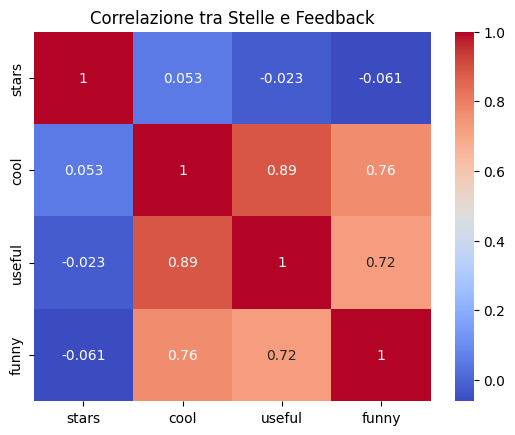

business_id    0
date           0
review_id      0
stars          0
text           0
type           0
user_id        0
cool           0
useful         0
funny          0
dtype: int64

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

df=pd.read_csv('yelp.csv')

#Esplorazione correlazione
stars_corr=df[['stars','cool','useful','funny']].corr()

sns.heatmap(stars_corr,annot=True,cmap='coolwarm')
plt.title("Correlazione tra Stelle e Feedback")
plt.show()
df.describe()
df.isnull().sum()

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

X=df[['cool','useful','funny']]
y=df['stars']

def evaluate_linear_regression(X_data,y_data):
    X_train,X_test,y_train,y_test=train_test_split(X_data,y_data,test_size=0.2,random_state=1)
    linreg=LinearRegression()
    linreg.fit(X_train,y_train)
    y_pred=linreg.predict(X_test)
    return np.sqrt(metrics.mean_squared_error(y_test,y_pred))

rmse_all=evaluate_linear_regression(X,y)
print(f"RMSE con tutte le feature: {rmse_all:.4f}")

#Se provo a togliere funny, se il valore diminuisce allora significa che quella feature
#aggiungeva "rumore" invece di informazione utile al modello
new_rmse=evaluate_linear_regression(df[['cool','useful']],y)
print(f"RMSE senza funny: {new_rmse:.4f}")

RMSE con tutte le feature: 1.1837
RMSE senza funny: 1.1963


In [16]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

'''Dato che le SVM sono sensibili alla scala dobbiamo standardizzare i dati'''
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_train_s,X_test_s,y_train_s,y_test_s=train_test_split(X_scaled,y,test_size=0.2,random_state=1)

#Inizializzazione e training SVM, usiamo il kernel RBF per gestire le relazioni non lineari
model_svm=SVC(kernel='rbf')
model_svm.fit(X_train_s,y_train_s)

y_pred_svm=model_svm.predict(X_test_s)
accuracy=accuracy_score(y_test_s,y_pred_svm)
print(f"Accuratezza SVM: {accuracy:.2%}")
print("Report di classificazione: ")
print(classification_report(y_test_s,y_pred_svm))

Accuratezza SVM: 35.25%
Report di classificazione: 
              precision    recall  f1-score   support

           1       0.42      0.03      0.06       147
           2       0.11      0.01      0.01       186
           3       0.00      0.00      0.00       288
           4       0.35      0.97      0.52       706
           5       0.33      0.02      0.04       673

    accuracy                           0.35      2000
   macro avg       0.24      0.21      0.13      2000
weighted avg       0.28      0.35      0.20      2000



C:\Users\gfili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gfili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gfili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

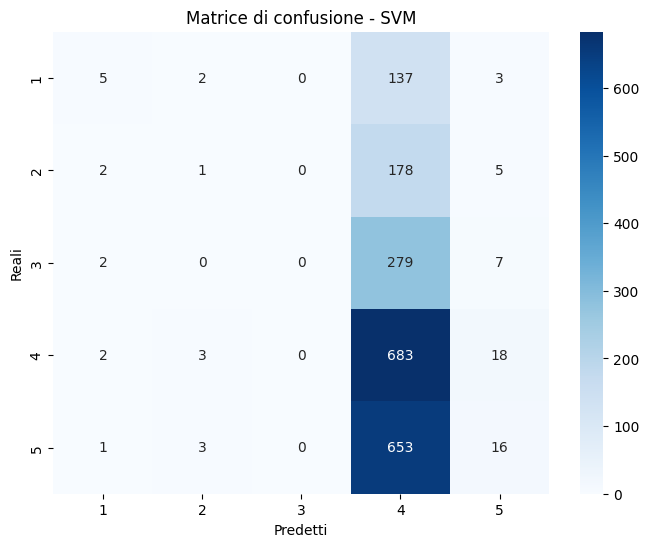

In [17]:
cm=confusion_matrix(y_test_s,y_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=[1,2,3,4,5],yticklabels=[1,2,3,4,5])

plt.xlabel("Predetti")
plt.ylabel("Reali")
plt.title("Matrice di confusione - SVM")
plt.show()